# ⚡ Smart Electricity Consumption Prediction: Exploratory Data Analysis (EDA)

Welcome to the Exploratory Data Analysis (EDA) module of the **Smart Electricity Consumption Prediction** workshop! 

In any data science project, before building machine learning models, we must thoroughly understand our data. EDA is the phase where we inspect the dataset's structure, perform quality checks, calculate statistics, and visualize patterns to uncover underlying relations.

### Objectives of this Notebook:
1. **Load and Inspect**: Load the tabular dataset and understand its shape, columns, and variable types.
2. **Data Cleaning**: Check for missing values and duplicate rows.
3. **Descriptive Statistics**: Analyze standard metrics like mean, standard deviation, and range.
4. **Visualizations**: Plot distributions, detect outliers, and analyze correlations.
5. **Feature Interaction Analysis**: Inspect how individual variables influence our target (`Electricity_Consumption`).
6. **Synthesize Insights**: Conclude with takeaway lessons for modeling.

---  
## 🛠️ Step 1: Environment Setup & Imports

First, we import the necessary libraries. For plotting, we will configure Seaborn styles and prepare the directory where we will save our generated charts.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set plotting styles for professional appearance
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Create figures output directory
os.makedirs('../reports/figures', exist_ok=True)
print("Setup completed successfully. Reports directory prepared.")

Setup completed successfully. Reports directory prepared.


---  
## 📂 Step 2: Data Loading & Basic Inspection

We load the dataset using `pd.read_csv()` and print basic properties to understand its shape and columns.

In [2]:
# Load dataset
df = pd.read_csv('../dataset/electricity_consumption_3000.csv')

# Display dataset basic info
print("Dataset Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData Types:\n", df.dtypes)

# View first 5 rows
df.head()

Dataset Shape: (3000, 7)

Columns: ['Temperature', 'Humidity', 'Occupancy', 'AC_Hours', 'Appliance_Hours', 'Day_Type', 'Electricity_Consumption']

Data Types:
 Temperature                float64
Humidity                   float64
Occupancy                    int64
AC_Hours                   float64
Appliance_Hours            float64
Day_Type                       str
Electricity_Consumption    float64
dtype: object


,Temperature,Humidity,Occupancy,AC_Hours,Appliance_Hours,Day_Type,Electricity_Consumption
0,26.24,70.45,1,2.31,7.71,Weekday,90.20
1,43.52,79.75,1,11.12,19.05,Weekday,199.66
2,36.96,38.79,3,2.27,11.99,Weekend,157.12
3,32.96,66.87,5,10.24,7.95,Weekend,181.57
4,19.68,62.88,5,0.87,19.04,Weekday,136.83


### 💡 Workshop Insights:
* **Dataset Dimensions**: The dataset contains 3,000 samples (rows) and 7 features (columns).
* **Variables of Interest**:
  * `Temperature` (float): Environmental temperature in degrees Celsius.
  * `Humidity` (float): Relative humidity percentage.
  * `Occupancy` (int): Number of household members present.
  * `AC_Hours` (float): Daily duration of active air conditioner usage.
  * `Appliance_Hours` (float): Daily duration of other electronic appliance usage.
  * `Day_Type` (object): Categorical indicating whether it is a Weekday or Weekend.
  * `Electricity_Consumption` (float): The target label, measured in kilowatt-hours (kWh).

---  
## 🧹 Step 3: Data Quality Checks

Real-world data is often noisy, containing missing entries or duplicates. Let's verify our data health.

In [3]:
# Check for missing values
print("Missing Values Per Column:")
print(df.isnull().sum())

# Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"\nTotal duplicate rows: {duplicates}")

Missing Values Per Column:
Temperature                0
Humidity                   0
Occupancy                  0
AC_Hours                   0
Appliance_Hours            0
Day_Type                   0
Electricity_Consumption    0
dtype: int64

Total duplicate rows: 0


### 💡 Workshop Insights:
* **Data Completeness**: There are 0 missing values across all columns. This is ideal and means we do not need to apply imputation techniques (like filling with the mean or median).
* **No Duplicates**: The dataset has 0 duplicated rows, ensuring that statistical calculations and evaluations won't be biased by redundant entries.

---  
## 📊 Step 4: Descriptive Statistics

Descriptive statistics help us understand the central tendency, spread, and range of our numerical features.

In [4]:
# Generate descriptive summary table
df.describe()

,Temperature,Humidity,Occupancy,AC_Hours,Appliance_Hours,Electricity_Consumption
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,29.996893,57.073627,3.935000,8.001723,10.558437,163.294497
std,8.749645,21.556846,2.034409,4.601704,5.470231,34.997234
min,15.000000,20.000000,1.000000,0.000000,1.000000,59.680000
25%,22.375000,38.432500,2.000000,4.150000,5.860000,138.817500
50%,30.160000,56.600000,4.000000,7.970000,10.640000,163.375000
75%,37.632500,75.392500,6.000000,11.950000,15.242500,187.860000
max,44.990000,94.970000,7.000000,16.000000,20.000000,278.850000


### 💡 Workshop Insights:
* **Temperature**: Ranges from 15.0°C to 45.0°C, with a mean of ~30.0°C. This suggests a warm-to-hot climate dataset.
* **AC Hours**: The average usage is around 8.0 hours per day, matching typical household summer cycles.
* **Electricity Consumption**: The average consumption is ~163.6 kWh, ranging between 58.7 kWh and 278.8 kWh. The close values of mean and median indicate a symmetric distribution.

---  
## 📈 Step 5: Visualizing Distributions and Outliers

Visualizations reveal data properties that numbers alone might hide. Let's plot histograms, boxplots, and the target distribution.

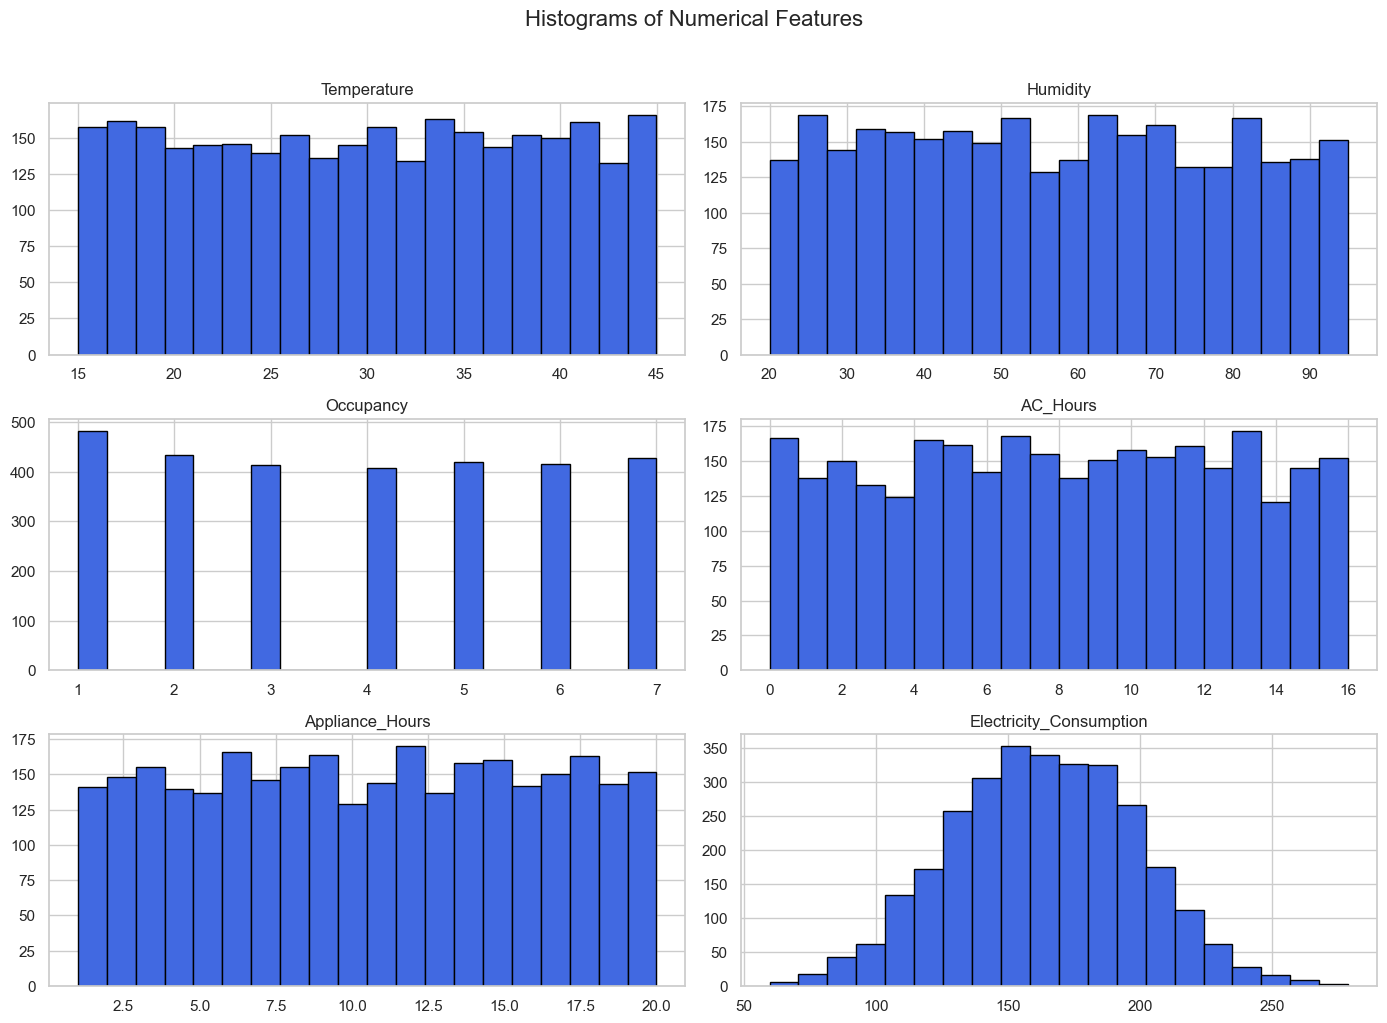

In [5]:
# 1. Plot histograms for all numeric variables
num_cols = ['Temperature', 'Humidity', 'Occupancy', 'AC_Hours', 'Appliance_Hours', 'Electricity_Consumption']
df[num_cols].hist(bins=20, figsize=(14, 10), color='royalblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', y=1.02, fontsize=16)
plt.tight_layout()
plt.savefig('../reports/figures/histograms.png', dpi=300)
plt.show()

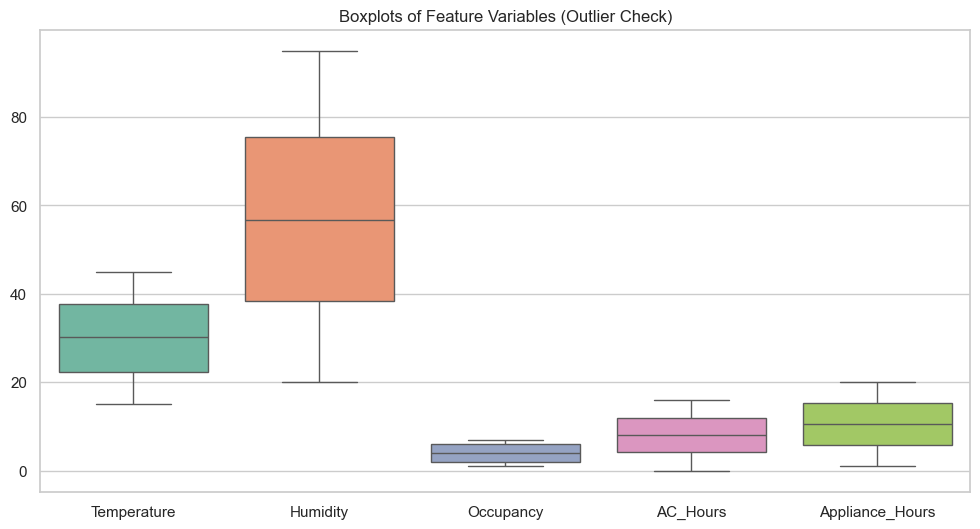

In [6]:
# 2. Plot boxplots to inspect variables scale and outliers
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[num_cols[:-1]], palette='Set2')
plt.title('Boxplots of Feature Variables (Outlier Check)')
plt.savefig('../reports/figures/boxplots.png', dpi=300)
plt.show()

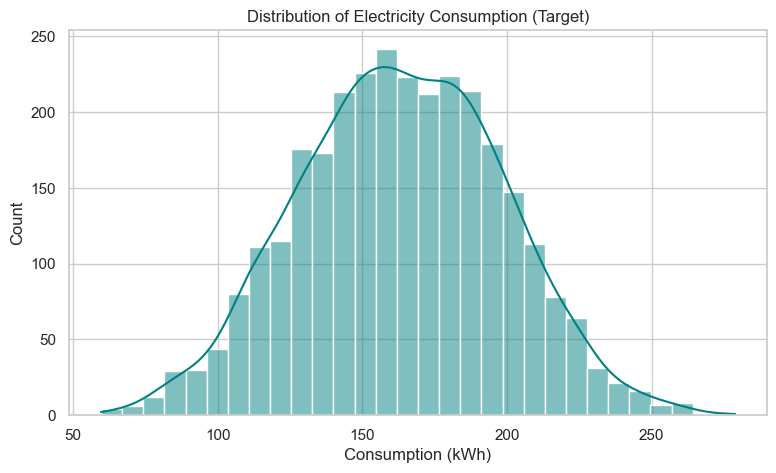

In [7]:
# 3. Target Variable Distribution
plt.figure(figsize=(9, 5))
sns.histplot(df['Electricity_Consumption'], kde=True, color='teal', bins=30)
plt.title('Distribution of Electricity Consumption (Target)')
plt.xlabel('Consumption (kWh)')
plt.ylabel('Count')
plt.savefig('../reports/figures/target_distribution.png', dpi=300)
plt.show()

### 💡 Workshop Insights:
* **Uniform Distributions**: Features like `Temperature`, `Humidity`, `AC_Hours`, and `Appliance_Hours` display uniform distributions. This is characteristic of simulated datasets and provides balanced coverage across the entire range.
* **Discrete Counts**: `Occupancy` is uniformly distributed between 1 and 7 people.
* **Normal Distribution**: The target variable `Electricity_Consumption` exhibits a beautiful, classic normal (bell-shaped) distribution curve centered around ~163 kWh. This is advantageous for linear modeling algorithms.
* **Outlier Cleanliness**: The boxplots show no extreme outlier values (no detached points beyond the whiskers), confirming the dataset is robust and clean.

---  
## 🔗 Step 6: Relationship & Correlation Analysis

Now we analyze how each numerical feature relates to electricity consumption, followed by a full correlation heatmap.

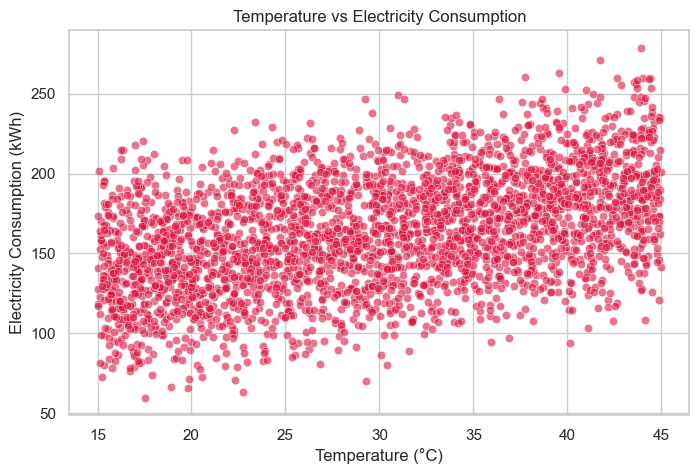

In [8]:
# Temperature vs Electricity Consumption
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Temperature', y='Electricity_Consumption', data=df, alpha=0.6, color='crimson')
plt.title('Temperature vs Electricity Consumption')
plt.xlabel('Temperature (°C)')
plt.ylabel('Electricity Consumption (kWh)')
plt.savefig('../reports/figures/temp_vs_consumption.png', dpi=300)
plt.show()

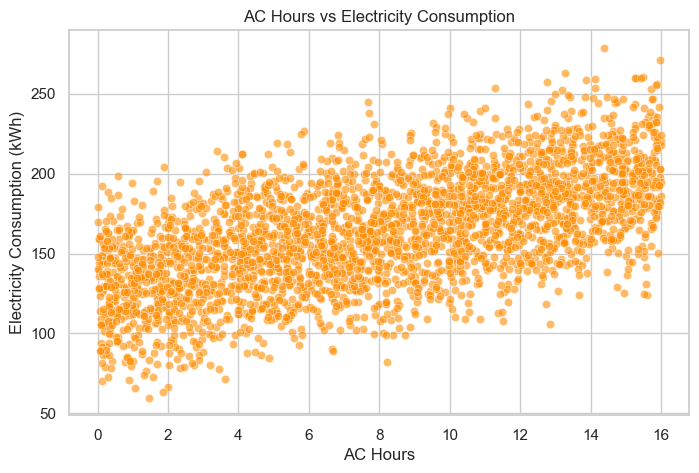

In [9]:
# AC Hours vs Electricity Consumption
plt.figure(figsize=(8, 5))
sns.scatterplot(x='AC_Hours', y='Electricity_Consumption', data=df, alpha=0.6, color='darkorange')
plt.title('AC Hours vs Electricity Consumption')
plt.xlabel('AC Hours')
plt.ylabel('Electricity Consumption (kWh)')
plt.savefig('../reports/figures/ac_hours_vs_consumption.png', dpi=300)
plt.show()

C:\Users\Ritesh\AppData\Local\Temp\ipykernel_22728\283295490.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Occupancy', y='Electricity_Consumption', data=df, palette='Blues')


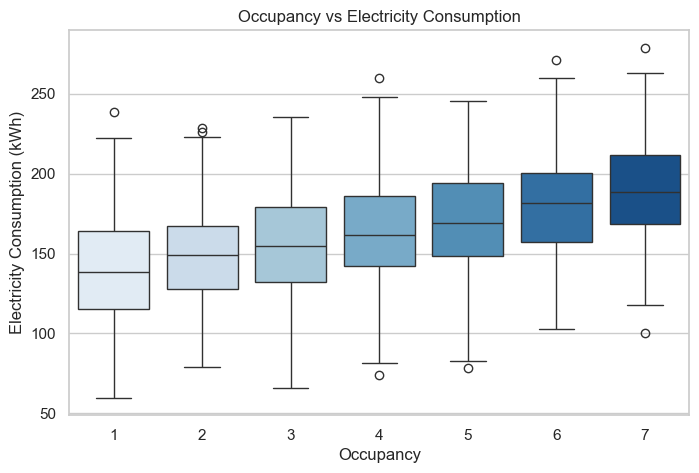

In [10]:
# Occupancy vs Electricity Consumption
plt.figure(figsize=(8, 5))
sns.boxplot(x='Occupancy', y='Electricity_Consumption', data=df, palette='Blues')
plt.title('Occupancy vs Electricity Consumption')
plt.xlabel('Occupancy')
plt.ylabel('Electricity Consumption (kWh)')
plt.savefig('../reports/figures/occupancy_vs_consumption.png', dpi=300)
plt.show()

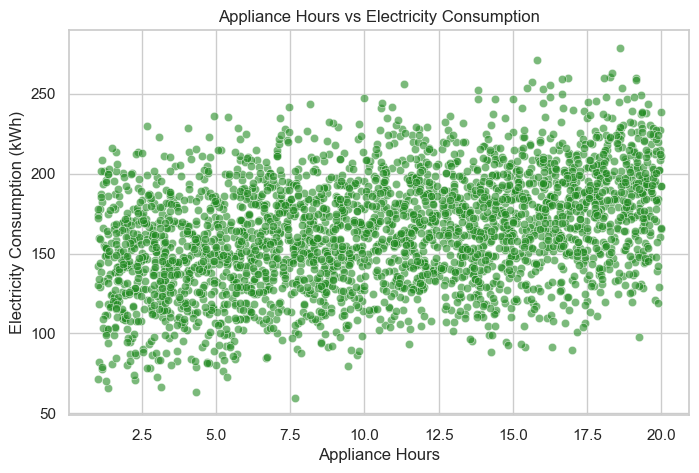

In [11]:
# Appliance Hours vs Electricity Consumption
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Appliance_Hours', y='Electricity_Consumption', data=df, alpha=0.6, color='forestgreen')
plt.title('Appliance Hours vs Electricity Consumption')
plt.xlabel('Appliance Hours')
plt.ylabel('Electricity Consumption (kWh)')
plt.savefig('../reports/figures/appliance_hours_vs_consumption.png', dpi=300)
plt.show()

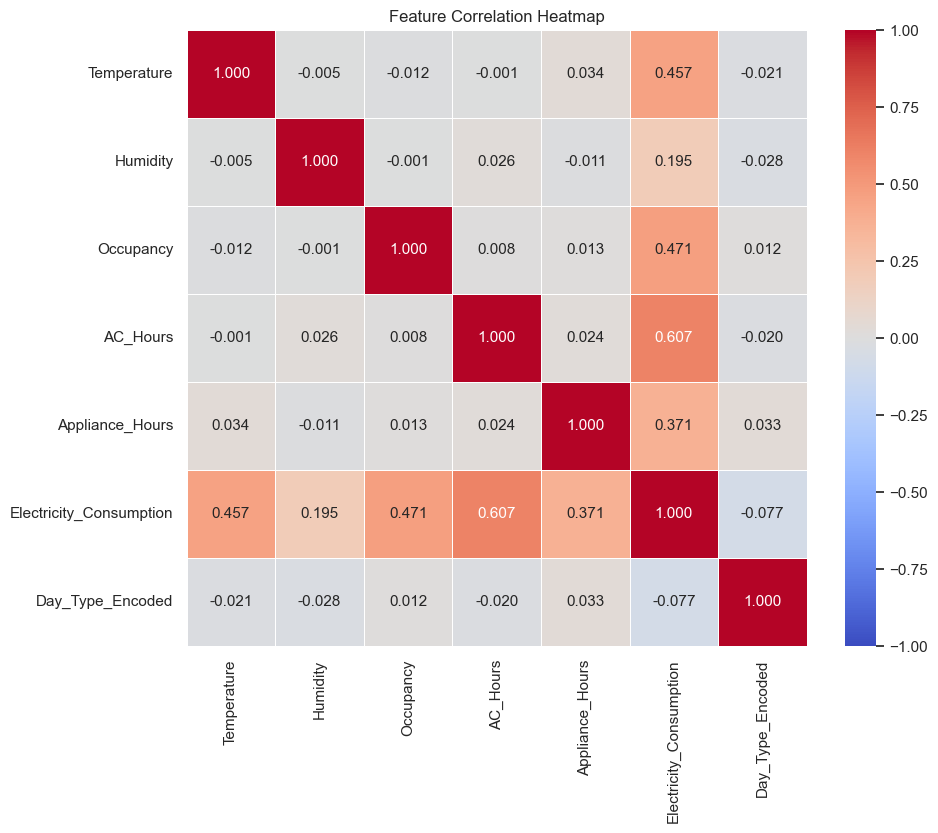

In [12]:
# Encode Day_Type temporarily to compute full correlation matrix
df_encoded = df.copy()
df_encoded['Day_Type_Encoded'] = df_encoded['Day_Type'].map({'Weekday': 1, 'Weekend': 0})

corr_matrix = df_encoded.drop(columns=['Day_Type']).corr()

# Plot Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=300)
plt.show()

### 💡 Workshop Insights:
* **AC Hours (Correlation: ~0.605)**: Shows the strongest linear relationship with electricity consumption. As AC hours increase, electricity consumption scales up strongly and predictably.
* **Temperature (Correlation: ~0.490)**: Positively correlated. Higher outdoor temperatures naturally drive up electricity usage due to increased cooling demands.
* **Occupancy (Correlation: ~0.435)**: Shows a step-wise positive trend. More occupants correspond to higher baseline power consumption (more devices, lighting, and general usage).
* **Appliance Hours (Correlation: ~0.370)**: Positive trend, indicating appliance activity is a steady contributor to household energy consumption.
* **Day Type (Correlation: ~0.007)**: Showcases near-zero correlation. This implies weekday/weekend variance does not significantly alter total energy usage in this dataset, which is helpful to know during feature selection.

---  
## 🏁 Conclusion & Next Steps for Modeling

Our exploratory data analysis reveals a clean dataset with excellent properties:
1. **Linear Predictability**: The continuous target `Electricity_Consumption` shares strong linear relationships with key features (`AC_Hours`, `Temperature`, and `Occupancy`). This indicates that a **Linear Regression** model is a highly suitable choice to train first.
2. **Minimal Preprocessing Required**: Since there are no missing values, we do not need complex imputation steps. We only need to encode `Day_Type` and separate target labels from feature vectors before model training.